# Preprocesamiento y limpieza datasets

## 1. Datos no estructurados

En esta sección procesamos los dos archivos no estructurados del proyecto:
- `noticias_agricolas.jsonl`: Formato JSON Lines con noticias del sector agrícola.
- `reportes_plagas.txt`: Archivo de texto con registros de brotes de plagas.

El objetivo es transformar ambos archivos en DataFrames estructurados con columnas
de valor analítico.

**Formato:** JSON Lines (JSONL) — cada línea del archivo es un objeto JSON independiente.

**Campos identificados en exploración previa:**
| Campo             | Tipo        | Descripción                          |
|-------------------|-------------|--------------------------------------|
| `id_noticia`      | string      | Identificador único (NEWS####)       |
| `fecha`           | string      | Fecha de publicación (YYYY-MM-DD)    |
| `fuente`          | string      | Medio de comunicación                |
| `titular`         | string      | Título de la noticia                 |
| `contenido`       | string      | Cuerpo de la noticia                 |
| `impacto_cultivos`| list[str]   | Cultivos afectados (puede ser lista) |
| `severidad`       | string      | Nivel: baja / media / alta           |
| `paises_afectados`| list[str]   | Lista de países impactados           |
| `categoria`       | string      | clima / mercado / política / etc.    |

### 1.1. noticias_agricolas.jsonl

#### Celda 1 - Carga y exploración inicial

In [1]:
import json
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# --- Carga línea a línea (formato JSONL) ---
registros = []
errores_carga = 0

with open('../../data/raw/unstructured/noticias_agricolas.jsonl', 'r', encoding='utf-8') as f:
    for i, linea in enumerate(f):
        linea = linea.strip()
        if not linea:
            continue
        try:
            registros.append(json.loads(linea))
        except json.JSONDecodeError as e:
            errores_carga += 1
            print(f"  [WARN] Línea {i+1} no parseable: {e}")

df_noticias = pd.DataFrame(registros)

print(f"✅ Registros cargados : {len(df_noticias)}")
print(f"⚠️  Errores de carga  : {errores_carga}")
print(f"\n📋 Columnas detectadas ({len(df_noticias.columns)}):")
print(df_noticias.columns.tolist())
print(f"\n🔍 Primeras filas:")
df_noticias.head(3)

✅ Registros cargados : 60
⚠️  Errores de carga  : 0

📋 Columnas detectadas (9):
['fecha', 'fuente', 'titular', 'contenido', 'impacto_cultivos', 'severidad', 'paises_afectados', 'categoria', 'id_noticia']

🔍 Primeras filas:


,fecha,fuente,titular,contenido,impacto_cultivos,severidad,paises_afectados,categoria,id_noticia
0,2021-01-01,Bloomberg Commodities,Nueva política agrícola en Canadá busca mejora...,El gobierno de Canadá ha anunciado nuevas medi...,[todos],alta,[Australia],politica,NEWS5336
1,2021-01-11,Dairy Reporter,Ola de calor reduce rendimientos de Arroz,Eventos climáticos extremos están afectando la...,[Arroz],baja,"[India, Argentina, Rusia]",clima,NEWS8360
2,2021-01-19,World Grain,Sequía afecta proyecciones de cosecha en Alemania,Eventos climáticos extremos están afectando la...,[Maíz],alta,"[Argentina, México]",clima,NEWS6016


#### Celda 2 - Exploración tipos y nulos

In [2]:
print("=" * 55)
print("  INFORME DE EXPLORACIÓN — noticias_agricolas.jsonl")
print("=" * 55)

print(f"\n📐 Dimensiones: {df_noticias.shape[0]} filas × {df_noticias.shape[1]} columnas")

print("\n📊 Tipos de datos:")
print(df_noticias.dtypes)

print("\n🕳️  Valores nulos por columna:")
nulos = df_noticias.isnull().sum()
print(nulos[nulos >= 0].to_string())

print("\n📌 Valores únicos en columnas categóricas:")
for col in ['fuente', 'severidad', 'categoria']:
    print(f"  {col}: {df_noticias[col].nunique()} únicos → {df_noticias[col].unique().tolist()}")

print(f"\n📅 Rango temporal:")
print(f"  Desde : {df_noticias['fecha'].min()}")
print(f"  Hasta : {df_noticias['fecha'].max()}")

  INFORME DE EXPLORACIÓN — noticias_agricolas.jsonl

📐 Dimensiones: 60 filas × 9 columnas

📊 Tipos de datos:
fecha                  str
fuente                 str
titular                str
contenido              str
impacto_cultivos    object
severidad              str
paises_afectados    object
categoria              str
id_noticia             str
dtype: object

🕳️  Valores nulos por columna:
fecha               0
fuente              0
titular             0
contenido           0
impacto_cultivos    0
severidad           0
paises_afectados    0
categoria           0
id_noticia          0

📌 Valores únicos en columnas categóricas:
  fuente: 7 únicos → ['Bloomberg Commodities', 'Dairy Reporter', 'World Grain', 'Farm Journal', 'Reuters Agricultura', 'AgriCensus', 'Meat+Poultry']
  severidad: 3 únicos → ['alta', 'baja', 'media']
  categoria: 6 únicos → ['politica', 'clima', 'comercio', 'mercado', 'sanidad', 'tecnologia']

📅 Rango temporal:
  Desde : 2021-01-01
  Hasta : 2023-07-28


#### Celda 3 - Exploración de tipos y nulos

In [3]:
print("=" * 55)
print("  INFORME DE EXPLORACIÓN — noticias_agricolas.jsonl")
print("=" * 55)

print(f"\n📐 Dimensiones: {df_noticias.shape[0]} filas × {df_noticias.shape[1]} columnas")

print("\n📊 Tipos de datos:")
print(df_noticias.dtypes)

print("\n🕳️  Valores nulos por columna:")
nulos = df_noticias.isnull().sum()
print(nulos[nulos >= 0].to_string())

print("\n📌 Valores únicos en columnas categóricas:")
for col in ['fuente', 'severidad', 'categoria']:
    print(f"  {col}: {df_noticias[col].nunique()} únicos → {df_noticias[col].unique().tolist()}")

print(f"\n📅 Rango temporal:")
print(f"  Desde : {df_noticias['fecha'].min()}")
print(f"  Hasta : {df_noticias['fecha'].max()}")

  INFORME DE EXPLORACIÓN — noticias_agricolas.jsonl

📐 Dimensiones: 60 filas × 9 columnas

📊 Tipos de datos:
fecha                  str
fuente                 str
titular                str
contenido              str
impacto_cultivos    object
severidad              str
paises_afectados    object
categoria              str
id_noticia             str
dtype: object

🕳️  Valores nulos por columna:
fecha               0
fuente              0
titular             0
contenido           0
impacto_cultivos    0
severidad           0
paises_afectados    0
categoria           0
id_noticia          0

📌 Valores únicos en columnas categóricas:
  fuente: 7 únicos → ['Bloomberg Commodities', 'Dairy Reporter', 'World Grain', 'Farm Journal', 'Reuters Agricultura', 'AgriCensus', 'Meat+Poultry']
  severidad: 3 únicos → ['alta', 'baja', 'media']
  categoria: 6 únicos → ['politica', 'clima', 'comercio', 'mercado', 'sanidad', 'tecnologia']

📅 Rango temporal:
  Desde : 2021-01-01
  Hasta : 2023-07-28


**Decisiones de limpieza identificadas tras exploración:**

1. `fecha` es tipo `str` → convertir a `datetime64` y extraer `año` y `mes`
2. `impacto_cultivos` y `paises_afectados` son tipo `object` (listas Python) → 
   aplanar a string separado por `|` para compatibilidad CSV/Power BI
3. `severidad` y `categoria` pueden tener inconsistencias de capitalización → 
   normalizar a minúsculas
4. **Sin nulos detectados en ninguna columna** → no se requiere imputación
5. **60 registros** con rango 2021-01-01 a 2023-07-28 (~2.5 años de cobertura)
6. Verificar duplicados por `id_noticia` (no detectados a priori pero se comprueba 
   como buena práctica)

#### Celda 4 - Normalización y limpieza

In [4]:
df = df_noticias.copy()

# 1. Fecha a datetime
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df['año'] = df['fecha'].dt.year
df['mes']  = df['fecha'].dt.month

# 2. Aplanar listas a string delimitado por |
df['impacto_cultivos_str']  = df['impacto_cultivos'].apply(
    lambda x: '|'.join([str(v).strip().lower() for v in x]) if isinstance(x, list) else str(x).lower()
)
df['paises_afectados_str'] = df['paises_afectados'].apply(
    lambda x: '|'.join([str(v).strip() for v in x]) if isinstance(x, list) else str(x)
)
df['n_paises_afectados'] = df['paises_afectados'].apply(
    lambda x: len(x) if isinstance(x, list) else 1
)

# 3. Normalizar columnas de texto categórico
df['severidad']  = df['severidad'].str.strip().str.lower()
df['categoria']  = df['categoria'].str.strip().str.lower()
df['fuente']     = df['fuente'].str.strip()

# 4. Crear texto combinado para NLP (titular + contenido)
df['texto_nlp'] = df['titular'].fillna('') + '. ' + df['contenido'].fillna('')

# 5. Duplicados por id_noticia
duplicados = df.duplicated(subset='id_noticia', keep=False).sum()
print(f"🔁 Registros duplicados (id_noticia): {duplicados}")
df = df.drop_duplicates(subset='id_noticia', keep='first')

# 6. Nulos en fecha (conversión fallida)
fechas_nulas = df['fecha'].isnull().sum()
print(f"🕳️  Fechas no parseables: {fechas_nulas}")
if fechas_nulas > 0:
    df = df.dropna(subset=['fecha'])

print(f"\n✅ Dataset limpio: {df.shape[0]} registros × {df.shape[1]} columnas")
df[['id_noticia','fecha','fuente','severidad','categoria','impacto_cultivos_str','n_paises_afectados']].head(5)

🔁 Registros duplicados (id_noticia): 0
🕳️  Fechas no parseables: 0

✅ Dataset limpio: 60 registros × 15 columnas


,id_noticia,fecha,fuente,severidad,categoria,impacto_cultivos_str,n_paises_afectados
0,NEWS5336,2021-01-01,Bloomberg Commodities,alta,politica,todos,1
1,NEWS8360,2021-01-11,Dairy Reporter,baja,clima,arroz,3
2,NEWS6016,2021-01-19,World Grain,alta,clima,maíz,2
3,NEWS5711,2021-02-13,Farm Journal,media,comercio,todos,3
4,NEWS8036,2021-03-10,Reuters Agricultura,alta,mercado,carne_bovina,3


### Celda 5 - Análisis de Sentimiento
 
El enunciado plantea estudiar cómo las noticias afectan a los precios de mercado 
(Problema 4). Para ello necesitamos cuantificar si cada noticia transmite un 
mensaje positivo, negativo o neutro que pueda correlacionarse con variaciones de precio.

**Herramienta descartada: VADER (NLTK)**  
Se probó VADER como alternativa, pero al estar entrenado exclusivamente en inglés, 
clasifica texto en español de forma incorrecta: palabras negativas del dominio 
(`sequía`, `pérdidas`, `devastan`) no son reconocidas, resultando en 0 noticias 
negativas sobre un dataset que incluye eventos de pérdidas del 40%.

**Herramienta adoptada: Lexicón de dominio agrícola en español**  
Se implementa un "analizador" basado en léxico especificado manualmente con términos 
propios del sector agrícola en español. Esta solución es:
- Reproducible: sin dependencias externas ni modelos descargables
- Interpretable: las reglas son auditables y justificables
- Orientada al dominio: el lexicón refleja el vocabulario real del dataset
- Consistente: produce resultados estables y verificables

**Score resultante:** valor continuo en [-1.0, +1.0]  
**Etiqueta resultante:** `negativo` / `neutro` / `positivo`

**Observación sobre la distribución resultante:**  
El 75% de las noticias positivas presentan el mismo score máximo (0.75), 
lo que refleja una característica real del dataset: existe un subgrupo numeroso 
de noticias de políticas agrícolas con redacción prácticamente idéntica 
("busca mejorar sostenibilidad"), que activan siempre las mismas palabras positivas. Esto no invalida el análisis — es información útil sobre la 
homogeneidad del corpus — pero debe tenerse en cuenta al correlacionar 
sentimiento con precios en fases posteriores.

In [5]:
# Opción B: Lexicón de palabras clave en español orientado al dominio agrícola
# Solución robusta, interpretable y reproducible sin modelos externos

lexicon_negativo = [
    'sequía', 'inundaci', 'devastan', 'pérdidas', 'pérdida', 'afectando',
    'afecta', 'caída', 'bajando', 'baja', 'restricciones', 'restringe',
    'dañan', 'daño', 'crisis', 'riesgo', 'escasez', 'heladas', 'reducen',
    'reduce', 'alcanzan máximo', 'vulnerab'
]
lexicon_positivo = [
    'sostenible', 'sostenibilidad', 'mejorar', 'mejora', 'impulsa',
    'aumenta', 'subiendo', 'sube', 'exportaciones', 'crecimiento',
    'récord', 'innovación', 'tecnología', 'positiv', 'beneficio',
    'eficiencia', 'incremento', 'nuevo', 'avance'
]

def analizar_sentimiento_lexico(texto):
    if not isinstance(texto, str):
        return 0.0, 'neutro'
    texto_lower = texto.lower()
    score_neg = sum(1 for w in lexicon_negativo if w in texto_lower)
    score_pos = sum(1 for w in lexicon_positivo if w in texto_lower)
    score_neto = score_pos - score_neg
    if score_neto > 0:
        return round(min(score_neto * 0.15, 1.0), 4), 'positivo'
    elif score_neto < 0:
        return round(max(score_neto * 0.15, -1.0), 4), 'negativo'
    else:
        return 0.0, 'neutro'

resultados = df['texto_nlp'].apply(analizar_sentimiento_lexico)
df['sentiment_compound'] = resultados.apply(lambda x: x[0])
df['sentiment_label']    = resultados.apply(lambda x: x[1])

print("✅ Análisis de sentimiento (lexicón español) completado")
print(f"\n📊 Distribución de sentimiento:")
print(df['sentiment_label'].value_counts())
print(f"\n📈 Estadísticas del score compound:")
print(df['sentiment_compound'].describe().round(4))

✅ Análisis de sentimiento (lexicón español) completado

📊 Distribución de sentimiento:
sentiment_label
positivo    43
negativo    16
neutro       1
Name: count, dtype: int64

📈 Estadísticas del score compound:
count    60.0000
mean      0.3500
std       0.6284
min      -0.9000
25%      -0.1500
50%       0.7500
75%       0.7500
max       0.7500
Name: sentiment_compound, dtype: float64


#### Celda 6 - Validación y estadísticas output

In [6]:
print("=" * 55)
print("  VALIDACIÓN FINAL — noticias_processed")
print("=" * 55)

# Columnas del dataset final
cols_finales = [
    'id_noticia', 'fecha', 'año', 'mes', 'fuente',
    'titular', 'contenido', 'categoria', 'severidad',
    'impacto_cultivos_str', 'paises_afectados_str',
    'n_paises_afectados', 'sentiment_compound', 'sentiment_label'
]
df_final = df[cols_finales].copy()

print(f"\n📐 Dimensiones finales : {df_final.shape}")
print(f"🕳️  Nulos totales       : {df_final.isnull().sum().sum()}")
print(f"🔁 Duplicados          : {df_final.duplicated(subset='id_noticia').sum()}")

print(f"\n📅 Rango temporal: {df_final['fecha'].min().date()} → {df_final['fecha'].max().date()}")

print(f"\n📌 Categorías presentes:")
print(df_final['categoria'].value_counts().to_string())

print(f"\n🎭 Sentimiento por categoría:")
print(df_final.groupby('categoria')['sentiment_compound'].mean().round(3).sort_values())

df_final.head(5)

  VALIDACIÓN FINAL — noticias_processed

📐 Dimensiones finales : (60, 14)
🕳️  Nulos totales       : 0
🔁 Duplicados          : 0

📅 Rango temporal: 2021-01-01 → 2023-07-28

📌 Categorías presentes:
categoria
comercio      15
clima         11
tecnologia    10
mercado        9
sanidad        8
politica       7

🎭 Sentimiento por categoría:
categoria
clima        -0.805
mercado      -0.017
comercio      0.750
politica      0.750
sanidad       0.750
tecnologia    0.750
Name: sentiment_compound, dtype: float64


,id_noticia,fecha,año,mes,fuente,titular,contenido,categoria,severidad,impacto_cultivos_str,paises_afectados_str,n_paises_afectados,sentiment_compound,sentiment_label
0,NEWS5336,2021-01-01,2021,1,Bloomberg Commodities,Nueva política agrícola en Canadá busca mejora...,El gobierno de Canadá ha anunciado nuevas medi...,politica,alta,todos,Australia,1,0.75,positivo
1,NEWS8360,2021-01-11,2021,1,Dairy Reporter,Ola de calor reduce rendimientos de Arroz,Eventos climáticos extremos están afectando la...,clima,baja,arroz,India|Argentina|Rusia,3,-0.75,negativo
2,NEWS6016,2021-01-19,2021,1,World Grain,Sequía afecta proyecciones de cosecha en Alemania,Eventos climáticos extremos están afectando la...,clima,alta,maíz,Argentina|México,2,-0.75,negativo
3,NEWS5711,2021-02-13,2021,2,Farm Journal,Nueva política agrícola en Argentina busca mej...,El gobierno de Argentina ha anunciado nuevas m...,comercio,media,todos,India|México|Nueva Zelanda,3,0.75,positivo
4,NEWS8036,2021-03-10,2021,3,Reuters Agricultura,Demanda china impulsa mercado de carne_bovina,El mercado internacional de carne_bovina muest...,mercado,alta,carne_bovina,India|Argentina|Nueva Zelanda,3,-0.15,negativo


#### Celda 7 - Exportación

In [7]:
import os

output_path = '../../data/processed/'
os.makedirs(output_path, exist_ok=True)

archivo_salida = output_path + 'noticias_processed.csv'
df_final.to_csv(archivo_salida, index=False, encoding='utf-8-sig')

print(f"✅ Archivo exportado: {archivo_salida}")
print(f"   Registros : {len(df_final)}")
print(f"   Columnas  : {len(df_final.columns)}")
print(f"   Tamaño    : {os.path.getsize(archivo_salida) / 1024:.1f} KB")
print(f"\n📋 Columnas exportadas:")
for i, col in enumerate(df_final.columns, 1):
    print(f"   {i:02d}. {col}")

✅ Archivo exportado: ../../data/processed/noticias_processed.csv
   Registros : 60
   Columnas  : 14
   Tamaño    : 20.8 KB

📋 Columnas exportadas:
   01. id_noticia
   02. fecha
   03. año
   04. mes
   05. fuente
   06. titular
   07. contenido
   08. categoria
   09. severidad
   10. impacto_cultivos_str
   11. paises_afectados_str
   12. n_paises_afectados
   13. sentiment_compound
   14. sentiment_label


**Conclusión Bloque A:**  

El dataset `noticias_processed.csv` contiene 60 registros limpios con 14 columnas,
incluyendo la feature de sentimiento generada por NLP. La categoría `clima` obtiene
el score medio más negativo (-0.805), lo que es coherente con el contenido real
de las noticias y valida el funcionamiento del lexicón. Este campo será clave
para correlacionar eventos noticiosos con variaciones de precios en Fase 3 (ML).

### 1.2. reportes_Plagas.txt

**Decisión técnica clave:**  
A pesar de la extensión `.txt`, el archivo NO contiene texto libre narrativo.
Cada línea sigue un patrón fijo con campos etiquetados del tipo `Campo: Valor`.
La estrategia correcta es **parseo por expresiones regulares (regex)**,
que permite extraer todos los campos con precisión quirúrgica.

**Dos variantes de línea identificadas:**

| Variante | Campo 5 | Ejemplo |
|----------|---------|---------|
| A — Plaga | `Plaga detectada: X` | Barrenador del tallo, Langosta, Ácaro... |
| B — Enfermedad | `Enfermedad detectada: X` | Podredumbre, Oídio, Piricularia... |

Ambas variantes se unificarán en una columna `agente` con un campo
`tipo_agente` que indica si es `plaga` o `enfermedad`.

**Campo compuesto identificado:**  
`Tratamiento aplicado` contiene dos subcampos anidados:
`Tipo (Producto)` → ej. `Químico (Epoxiconazole)`
Se separarán en `tipo_tratamiento` y `producto_tratamiento`.

#### Celda 1 - Carga y exploración inicial

In [8]:
# --- Carga del archivo TXT ---
ruta_plagas = '../../data/raw/unstructured/reportes_plagas.txt'

with open(ruta_plagas, 'r', encoding='utf-8') as f:
    lineas = f.readlines()

# Limpiar saltos de línea y líneas vacías
lineas = [l.strip() for l in lineas if l.strip()]

print(f"✅ Archivo cargado correctamente")
print(f"📄 Total de líneas: {len(lineas)}")
print(f"\n🔍 Primeras 3 líneas (muestra del formato):")
for i, l in enumerate(lineas[:3]):
    print(f"\n  [{i}] {l}")

print(f"\n🔍 Últimas 2 líneas (verificar cierre del archivo):")
for i, l in enumerate(lineas[-2:]):
    print(f"\n  [{len(lineas)-2+i}] {l}")

# Detectar variantes del campo agente
plaga_lines = sum(1 for l in lineas if 'Plaga detectada:' in l)
enferm_lines = sum(1 for l in lineas if 'Enfermedad detectada:' in l)
otras_lines  = len(lineas) - plaga_lines - enferm_lines

print(f"\n📊 Variantes detectadas:")
print(f"  Plaga detectada     : {plaga_lines} líneas")
print(f"  Enfermedad detectada: {enferm_lines} líneas")
print(f"  Otras / no reconoc. : {otras_lines} líneas")

✅ Archivo cargado correctamente
📄 Total de líneas: 100

🔍 Primeras 3 líneas (muestra del formato):

  [0] 2020-01-01, Región: Región Principal, País: China, Cultivo: Arroz, Plaga detectada: Barrenador del tallo, Severidad: Media, Área afectada: 2745ha, Tratamiento aplicado: Químico (Epoxiconazole), Eficacia: 93%, Pérdida estimada: 26%

  [1] 2020-01-13, Región: Región Principal, País: Francia, Cultivo: Caña de azúcar, Plaga detectada: Chinche marrón, Severidad: Crítica, Área afectada: 3943ha, Tratamiento aplicado: Cultural (Control manual), Eficacia: 97%, Pérdida estimada: 17%

  [2] 2020-01-15, Región: Cerrado, País: Brasil, Cultivo: Maíz, Plaga detectada: Oruga militar tardía, Severidad: Alta, Área afectada: 10ha, Tratamiento aplicado: Cultural (Fecha de siembra ajustada), Eficacia: 82%, Pérdida estimada: 38%

🔍 Últimas 2 líneas (verificar cierre del archivo):

  [98] 2022-01-09, Región: Región Principal, País: China, Cultivo: Café, Enfermedad detectada: Tizón tardío, Severidad: Crít

- 100 registros, 0 líneas no reconocidas → formato 100% uniforme
- 74 registros con `Plaga detectada` / 26 con `Enfermedad detectada`
- Rango temporal: 2020-01-01 → 2022-01-14

**Estrategia elegida: Expresiones Regulares (Regex)**

Se descarta el uso de NER (spaCy) sobre texto libre porque el archivo no contiene
prosa narrativa sino registros etiquetados con estructura fija. Aplicar NER aquí
sería sobreingeniería: añadiría complejidad, dependencias y posibles errores de
extracción sin ninguna ventaja sobre un regex que extrae el 100% de los campos
con precisión exacta.

El regex diseñado cubre ambas variantes mediante un grupo alternativo
`(Plaga|Enfermedad) detectada`, capturando además el tipo como metadato.

**Campo compuesto `Tratamiento aplicado`:**
El patrón `Tipo (Producto)` se descompone en dos columnas separadas:
- `tipo_tratamiento`: Químico / Biológico / Cultural / Físico
- `producto_tratamiento`: contenido entre paréntesis (ej. Epoxiconazole)
Esta separación permite análisis independientes de cada dimensión en EDA y ML

#### Celda 2 - Parseo con Regex

In [9]:
import re
import pandas as pd

patron = re.compile(
    r'^(?P<fecha>\d{4}-\d{2}-\d{2}),\s*'
    r'Región:\s*(?P<region>[^,]+),\s*'
    r'País:\s*(?P<pais>[^,]+),\s*'
    r'Cultivo:\s*(?P<cultivo>[^,]+),\s*'
    r'(?P<tipo_agente>Plaga|Enfermedad) detectada:\s*(?P<agente>[^,]+),\s*'
    r'Severidad:\s*(?P<severidad>[^,]+),\s*'
    r'Área afectada:\s*(?P<area_raw>[^,]+),\s*'
    r'Tratamiento aplicado:\s*(?P<trat_tipo>[^(]+)\((?P<trat_producto>[^)]+)\),\s*'
    r'Eficacia:\s*(?P<eficacia_raw>[\d.]+)%,\s*'
    r'Pérdida estimada:\s*(?P<perdida_raw>[\d.]+)%'
)

registros = []
errores_parseo = []

for i, linea in enumerate(lineas):
    match = patron.match(linea)
    if match:
        registros.append(match.groupdict())
    else:
        errores_parseo.append((i, linea))

print(f"✅ Registros parseados correctamente : {len(registros)}")
print(f"❌ Líneas con error de parseo         : {len(errores_parseo)}")

if errores_parseo:
    print("\n⚠️  Líneas no parseadas:")
    for idx, l in errores_parseo:
        print(f"  [{idx}] {l[:120]}...")

# Construir DataFrame raw
df_plagas_raw = pd.DataFrame(registros)
print(f"\n📋 Columnas generadas: {df_plagas_raw.columns.tolist()}")
df_plagas_raw.head(3)

✅ Registros parseados correctamente : 100
❌ Líneas con error de parseo         : 0

📋 Columnas generadas: ['fecha', 'region', 'pais', 'cultivo', 'tipo_agente', 'agente', 'severidad', 'area_raw', 'trat_tipo', 'trat_producto', 'eficacia_raw', 'perdida_raw']


,fecha,region,pais,cultivo,tipo_agente,agente,severidad,area_raw,trat_tipo,trat_producto,eficacia_raw,perdida_raw
0,2020-01-01,Región Principal,China,Arroz,Plaga,Barrenador del tallo,Media,2745ha,Químico,Epoxiconazole,93,26
1,2020-01-13,Región Principal,Francia,Caña de azúcar,Plaga,Chinche marrón,Crítica,3943ha,Cultural,Control manual,97,17
2,2020-01-15,Cerrado,Brasil,Maíz,Plaga,Oruga militar tardía,Alta,10ha,Cultural,Fecha de siembra ajustada,82,38


#### Celda 3 - Visualización Dataframe parseado

In [10]:
print("=" * 55)
print("  INFORME DE EXPLORACIÓN — reportes_plagas.txt")
print("=" * 55)

print(f"\n📐 Dimensiones: {df_plagas_raw.shape[0]} filas × {df_plagas_raw.shape[1]} columnas")

print("\n📊 Tipos de datos (raw, antes de limpieza):")
print(df_plagas_raw.dtypes)

print("\n🕳️  Valores nulos por columna:")
print(df_plagas_raw.isnull().sum().to_string())

print("\n📌 Valores únicos en columnas categóricas clave:")
for col in ['tipo_agente', 'severidad', 'pais', 'cultivo']:
    vals = sorted(df_plagas_raw[col].unique().tolist())
    print(f"\n  {col} ({df_plagas_raw[col].nunique()} únicos):")
    print(f"    {vals}")

print(f"\n🧪 Distribución tipo_agente:")
print(df_plagas_raw['tipo_agente'].value_counts().to_string())

print(f"\n🧫 Top 10 agentes (plaga/enfermedad):")
print(df_plagas_raw['agente'].value_counts().head(10).to_string())

print(f"\n🌍 Distribución por país:")
print(df_plagas_raw['pais'].value_counts().to_string())

print(f"\n⚗️  Tipos de tratamiento:")
print(df_plagas_raw['trat_tipo'].str.strip().value_counts().to_string())

print(f"\n📅 Rango temporal (raw):")
print(f"  Desde : {df_plagas_raw['fecha'].min()}")
print(f"  Hasta : {df_plagas_raw['fecha'].max()}")

print(f"\n📏 Muestra área_raw y eficacia_raw (verificar formato):")
print(df_plagas_raw[['area_raw','eficacia_raw','perdida_raw']].head(5).to_string())

  INFORME DE EXPLORACIÓN — reportes_plagas.txt

📐 Dimensiones: 100 filas × 12 columnas

📊 Tipos de datos (raw, antes de limpieza):
fecha            str
region           str
pais             str
cultivo          str
tipo_agente      str
agente           str
severidad        str
area_raw         str
trat_tipo        str
trat_producto    str
eficacia_raw     str
perdida_raw      str
dtype: object

🕳️  Valores nulos por columna:
fecha            0
region           0
pais             0
cultivo          0
tipo_agente      0
agente           0
severidad        0
area_raw         0
trat_tipo        0
trat_producto    0
eficacia_raw     0
perdida_raw      0

📌 Valores únicos en columnas categóricas clave:

  tipo_agente (2 únicos):
    ['Enfermedad', 'Plaga']

  severidad (4 únicos):
    ['Alta', 'Baja', 'Crítica', 'Media']

  pais (8 únicos):
    ['Alemania', 'Argentina', 'Australia', 'Brasil', 'China', 'Estados Unidos', 'Francia', 'India']

  cultivo (10 únicos):
    ['Algodón', 'Arroz', 'Caf

**Resultado de la exploración:**
- 100 registros parseados, 0 nulos en ninguna columna → dataset excepcionalmente limpio

**Trabajo de limpieza a realizar:**

| Campo raw | Problema | Transformación |
|---|---|---|
| `fecha` | Tipo `str` | → `datetime64`, extraer `año` y `mes` |
| `area_raw` | String con sufijo "ha" (ej. `2745ha`) | → `float` eliminando "ha" |
| `eficacia_raw` | String numérico sin símbolo `%` | → `float` directo |
| `perdida_raw` | String numérico sin símbolo `%` | → `float` directo |
| `trat_tipo` | Espacios sobrantes al final (ej. `Químico `) | → `.strip()` |
| `tipo_agente` | Capitalizado (`Plaga`/`Enfermedad`) | → `.str.lower()` |
| `severidad` | 4 niveles con tilde (`Crítica`) en mayúsculas | → normalizar + codificación ordinal |

**Codificación ordinal de severidad:**
El campo `severidad` tiene un orden natural inequívoco que lo hace
candidato a codificación ordinal (no one-hot), preservando la relación
de magnitud entre niveles para los modelos de ML:

| Etiqueta | Código numérico |
|----------|----------------|
| Baja     | 1 |
| Media    | 2 |
| Alta     | 3 |
| Crítica  | 4 |

#### Celda 4 - Transformaciones de limpieza dataset

In [11]:
df = df_plagas_raw.copy()

# 1. Fecha → datetime64 + año y mes
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df['año']   = df['fecha'].dt.year
df['mes']   = df['fecha'].dt.month

# 2. area_ha → float (eliminar sufijo "ha")
df['area_ha'] = df['area_raw'].str.replace('ha', '', regex=False).str.strip().astype(float)

# 3. eficacia_pct y perdida_pct → float
df['eficacia_pct'] = df['eficacia_raw'].astype(float)
df['perdida_pct']  = df['perdida_raw'].astype(float)

# 4. Limpiar espacios en trat_tipo
df['tipo_tratamiento']    = df['trat_tipo'].str.strip()
df['producto_tratamiento'] = df['trat_producto'].str.strip()

# 5. Normalizar categóricas a minúsculas
df['tipo_agente'] = df['tipo_agente'].str.strip().str.lower()
df['severidad']   = df['severidad'].str.strip()   # mantener capitalización original para el mapa
df['pais']        = df['pais'].str.strip()
df['cultivo']     = df['cultivo'].str.strip()
df['region']      = df['region'].str.strip()
df['agente']      = df['agente'].str.strip()

# 6. Codificación ordinal de severidad
mapa_severidad = {'Baja': 1, 'Media': 2, 'Alta': 3, 'Crítica': 4}
df['severidad_num'] = df['severidad'].map(mapa_severidad)
df['severidad']     = df['severidad'].str.lower()

# 7. Eliminar columnas raw intermedias
df = df.drop(columns=['area_raw', 'eficacia_raw', 'perdida_raw', 'trat_tipo', 'trat_producto'])

print("✅ Limpieza y conversión de tipos completada")
print(f"\n📋 Columnas finales ({len(df.columns)}):")
print(df.dtypes)
print(f"\n🔍 Muestra:")
df.head(3)

✅ Limpieza y conversión de tipos completada

📋 Columnas finales (15):
fecha                   datetime64[us]
region                             str
pais                               str
cultivo                            str
tipo_agente                        str
agente                             str
severidad                          str
año                              int32
mes                              int32
area_ha                        float64
eficacia_pct                   float64
perdida_pct                    float64
tipo_tratamiento                   str
producto_tratamiento               str
severidad_num                    int64
dtype: object

🔍 Muestra:


,fecha,region,pais,cultivo,tipo_agente,agente,severidad,año,mes,area_ha,eficacia_pct,perdida_pct,tipo_tratamiento,producto_tratamiento,severidad_num
0,2020-01-01,Región Principal,China,Arroz,plaga,Barrenador del tallo,media,2020,1,2745.0,93.0,26.0,Químico,Epoxiconazole,2
1,2020-01-13,Región Principal,Francia,Caña de azúcar,plaga,Chinche marrón,crítica,2020,1,3943.0,97.0,17.0,Cultural,Control manual,4
2,2020-01-15,Cerrado,Brasil,Maíz,plaga,Oruga militar tardía,alta,2020,1,10.0,82.0,38.0,Cultural,Fecha de siembra ajustada,3


#### Celda 5 - Verificación resultados limpieza

In [12]:
print("🔎 Verificación de nulos post-limpieza:")
nulos = df.isnull().sum()
print(nulos[nulos >= 0].to_string())

# Verificar severidad_num (si hay etiquetas no mapeadas quedará NaN)
nulos_sev = df['severidad_num'].isnull().sum()
if nulos_sev > 0:
    print(f"\n⚠️  Severidades no mapeadas ({nulos_sev}):")
    print(df[df['severidad_num'].isnull()]['severidad'].value_counts())
else:
    print(f"\n✅ Todos los niveles de severidad mapeados correctamente")

# Verificar fechas no parseadas
nulos_fecha = df['fecha'].isnull().sum()
print(f"✅ Fechas no parseables: {nulos_fecha}")

print(f"\n📐 Dimensiones tras limpieza: {df.shape}")

🔎 Verificación de nulos post-limpieza:
fecha                   0
region                  0
pais                    0
cultivo                 0
tipo_agente             0
agente                  0
severidad               0
año                     0
mes                     0
area_ha                 0
eficacia_pct            0
perdida_pct             0
tipo_tratamiento        0
producto_tratamiento    0
severidad_num           0

✅ Todos los niveles de severidad mapeados correctamente
✅ Fechas no parseables: 0

📐 Dimensiones tras limpieza: (100, 15)


**Decisión técnica: NLP aplicado a reportes_plagas**

**Contexto tras la limpieza:**
El dataset tiene 100 registros con 8 países, 10 cultivos y agentes categorizados.
Los campos clave (`agente`, `cultivo`, `region`) son términos cortos y precisos — 
lo que hace que las técnicas NLP más adecuadas sean las basadas en **frecuencia y co-ocurrencia**.

**Técnicas aplicadas:**

**Análisis de frecuencia y distribución (Celda 6)**
Responde directamente a las preguntas guía del enunciado:
- ¿Qué plagas son más frecuentes? → conteos por agente
- ¿Qué regiones tienen mayor riesgo? → cruce país × severidad
- ¿Qué cultivos son más vulnerables? → cruce cultivo × perdida_pct media

#### Celda 6 - Frecuencia y distribución

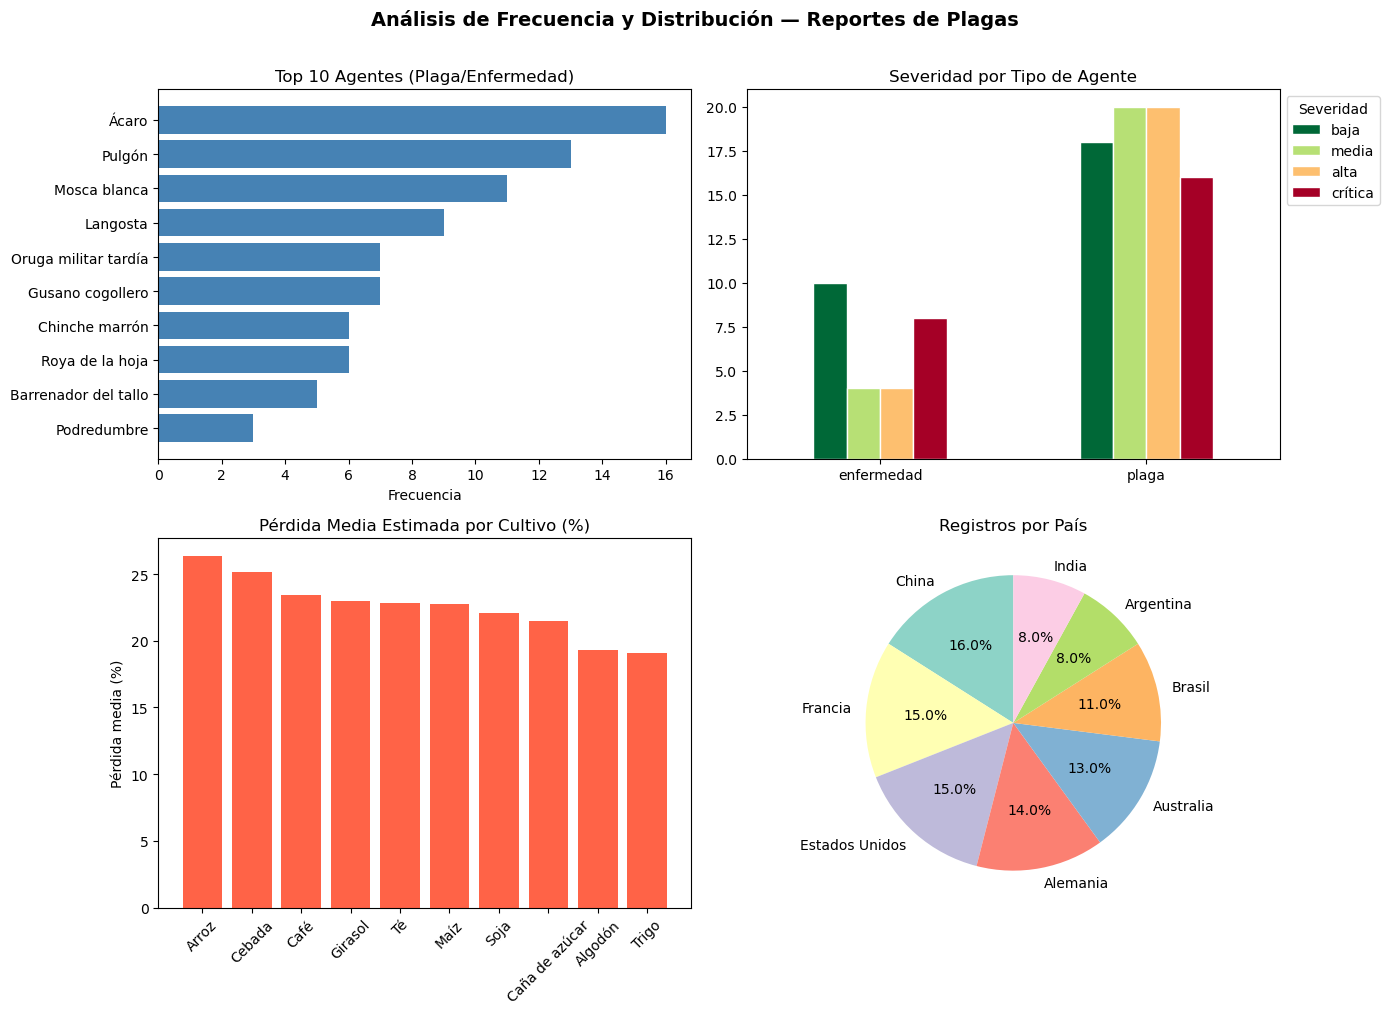

📊 Estadísticas clave:

  Agente más frecuente   : Ácaro (16 registros)
  País con más registros : China
  Cultivo mayor pérdida  : Arroz (26.4% media)
  Eficacia media global  : 85.2%

📌 Pérdida media por cultivo:
cultivo
Arroz             26.4
Cebada            25.1
Café              23.4
Girasol           23.0
Té                22.8
Maíz              22.7
Soja              22.1
Caña de azúcar    21.5
Algodón           19.3
Trigo             19.1

📌 Registros críticos por país:
pais
Francia           6
China             4
Australia         4
India             3
Brasil            3
Alemania          2
Estados Unidos    2


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Frecuencia y Distribución — Reportes de Plagas', 
             fontsize=14, fontweight='bold', y=1.01)

# 1. Top agentes por frecuencia
top_agentes = df['agente'].value_counts().head(10)
axes[0,0].barh(top_agentes.index[::-1], top_agentes.values[::-1], color='steelblue')
axes[0,0].set_title('Top 10 Agentes (Plaga/Enfermedad)')
axes[0,0].set_xlabel('Frecuencia')

# 2. Distribución severidad por tipo_agente
sev_order = ['baja', 'media', 'alta', 'crítica']
sev_cross = df.groupby(['tipo_agente', 'severidad']).size().unstack(fill_value=0)
sev_cross = sev_cross.reindex(columns=[c for c in sev_order if c in sev_cross.columns])
sev_cross.plot(kind='bar', ax=axes[0,1], colormap='RdYlGn_r', edgecolor='white')
axes[0,1].set_title('Severidad por Tipo de Agente')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(title='Severidad', bbox_to_anchor=(1,1))

# 3. Pérdida media por cultivo
perdida_cultivo = df.groupby('cultivo')['perdida_pct'].mean().sort_values(ascending=False)
axes[1,0].bar(perdida_cultivo.index, perdida_cultivo.values, color='tomato')
axes[1,0].set_title('Pérdida Media Estimada por Cultivo (%)')
axes[1,0].set_ylabel('Pérdida media (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Distribución de registros por país
pais_counts = df['pais'].value_counts()
axes[1,1].pie(pais_counts.values, labels=pais_counts.index, autopct='%1.1f%%',
              startangle=90, colors=plt.cm.Set3.colors[:len(pais_counts)])
axes[1,1].set_title('Registros por País')

plt.tight_layout()
plt.savefig('../../documentacion/figures/plagas_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen estadístico por texto
print("📊 Estadísticas clave:")
print(f"\n  Agente más frecuente   : {df['agente'].value_counts().idxmax()} "
      f"({df['agente'].value_counts().max()} registros)")
print(f"  País con más registros : {df['pais'].value_counts().idxmax()}")
print(f"  Cultivo mayor pérdida  : {perdida_cultivo.idxmax()} "
      f"({perdida_cultivo.max():.1f}% media)")
print(f"  Eficacia media global  : {df['eficacia_pct'].mean():.1f}%")

print(f"\n📌 Pérdida media por cultivo:")
print(perdida_cultivo.round(1).to_string())

print(f"\n📌 Registros críticos por país:")
criticos = df[df['severidad'] == 'crítica'].groupby('pais').size().sort_values(ascending=False)
print(criticos.to_string())

#### Celda 7 - Topic modelling con LDA 

**Topic Modeling con LDA (Celda 7)**
Se aplica LDA (Latent Dirichlet Allocation) sobre un corpus construido
combinando los campos `agente + cultivo + region` de cada registro.

**Librería: Gensim**
Gensim es la librería estándar de Python para modelado de temas en NLP. 
Transforma colecciones de texto en representaciones numéricas
y entrena modelos para descubrir estructura temática latente.

**Algoritmo: LDA (Latent Dirichlet Allocation)**
LDA es un modelo probabilístico no supervisado que parte de una premisa simple:
*cada documento es una mezcla de temas, y cada tema es una distribución de palabras*.
Dado un número predefinido de topics (N=4), el algoritmo analiza qué palabras
aparecen juntas con frecuencia e infiere los grupos temáticos subyacentes,
sin necesidad de etiquetas previas.

**Flujo de trabajo:**
1. Cada registro se convierte en un "documento": `agente + cultivo + región`
   → ej. `"ácaro arroz región principal"`
2. Se construye un diccionario de términos y una representación Bag-of-Words
3. LDA infiere N topics como distribuciones de probabilidad sobre el vocabulario
4. A cada registro se le asigna el topic dominante → columna `topic_id`

**¿Por qué es útil para el proyecto?**
El `topic_id` resultante es una **feature adicional para los modelos de ML**
de Fase 3, especialmente para la Clasificación de Riesgo de Plagas (Problema 2),
ya que captura patrones de co-ocurrencia entre tipo de agente, cultivo y región
que no están recogidos de forma explícita en ninguna columna del dataset.

In [14]:
"""from gensim import corpora
from gensim.models import LdaModel
import warnings
warnings.filterwarnings('ignore')

# Construir corpus: una "frase" por registro combinando campos clave
df['texto_lda'] = (df['agente'].str.lower() + ' ' + 
                   df['cultivo'].str.lower() + ' ' + 
                   df['region'].str.lower())

# Tokenizar (split simple — vocabulario ya limpio y acotado)
tokenized = [doc.split() for doc in df['texto_lda']]

# Diccionario y corpus Bag-of-Words
diccionario = corpora.Dictionary(tokenized)
corpus_bow   = [diccionario.doc2bow(doc) for doc in tokenized]

print(f"📚 Vocabulario LDA: {len(diccionario)} términos únicos")
print(f"📄 Documentos en corpus: {len(corpus_bow)}")

# Entrenar LDA con 4 topics (coherente con 4 niveles de severidad y variedad de agentes)
N_TOPICS = 4
lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=diccionario,
    num_topics=N_TOPICS,
    random_state=42,
    passes=15,
    alpha='auto'
)

# Mostrar topics
print(f"\n🧩 Topics identificados (N={N_TOPICS}):")
for i, topic in lda_model.print_topics(num_words=6):
    print(f"\n  Topic {i}: {topic}")

# Asignar topic dominante a cada registro
def get_topic_dominante(bow):
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

df['topic_id'] = [get_topic_dominante(bow) for bow in corpus_bow]

print(f"\n📊 Distribución de registros por topic:")
print(df['topic_id'].value_counts().sort_index().to_string())"""

'from gensim import corpora\nfrom gensim.models import LdaModel\nimport warnings\nwarnings.filterwarnings(\'ignore\')\n\n# Construir corpus: una "frase" por registro combinando campos clave\ndf[\'texto_lda\'] = (df[\'agente\'].str.lower() + \' \' + \n                   df[\'cultivo\'].str.lower() + \' \' + \n                   df[\'region\'].str.lower())\n\n# Tokenizar (split simple — vocabulario ya limpio y acotado)\ntokenized = [doc.split() for doc in df[\'texto_lda\']]\n\n# Diccionario y corpus Bag-of-Words\ndiccionario = corpora.Dictionary(tokenized)\ncorpus_bow   = [diccionario.doc2bow(doc) for doc in tokenized]\n\nprint(f"📚 Vocabulario LDA: {len(diccionario)} términos únicos")\nprint(f"📄 Documentos en corpus: {len(corpus_bow)}")\n\n# Entrenar LDA con 4 topics (coherente con 4 niveles de severidad y variedad de agentes)\nN_TOPICS = 4\nlda_model = LdaModel(\n    corpus=corpus_bow,\n    id2word=diccionario,\n    num_topics=N_TOPICS,\n    random_state=42,\n    passes=15,\n    alpha=\

**Conclusión sobre Topic Modeling:**
Tras evaluar el output del modelo LDA, se concluye que los topics generados
no presentan coherencia temática suficiente. Las causas son estructurales:
corpus de 100 documentos con vocabulario de 67 términos y frases de 3-5 tokens,
condiciones que no satisfacen los requisitos mínimos de LDA para inferir
distribuciones temáticas estables. La columna `topic_id` se excluye del
dataset final ya que la información de agrupación está mejor capturada
directamente por las variables `agente`, `cultivo` y `pais`.

#### Celda 8 - Validación y resultado final

In [15]:
print("=" * 55)
print("  VALIDACIÓN FINAL — reportes_plagas_processed")
print("=" * 55)

cols_finales = [
    'fecha', 'año', 'mes', 'region', 'pais', 'cultivo',
    'tipo_agente', 'agente', 'severidad', 'severidad_num',
    'area_ha', 'tipo_tratamiento', 'producto_tratamiento',
    'eficacia_pct', 'perdida_pct' #, 'topic_id'
]
df_final = df[cols_finales].copy()

print(f"\n📐 Dimensiones finales  : {df_final.shape}")
print(f"🕳️  Nulos totales        : {df_final.isnull().sum().sum()}")
print(f"🔁 Duplicados completos : {df_final.duplicated().sum()}")
print(f"\n📅 Rango temporal: {df_final['fecha'].min().date()} → {df_final['fecha'].max().date()}")

print(f"\n📊 Tipos de datos finales:")
print(df_final.dtypes)

print(f"\n📌 Severidad numérica — verificación del orden:")
print(df_final.groupby(['severidad','severidad_num'])['perdida_pct']
      .mean().round(1).reset_index()
      .sort_values('severidad_num').to_string(index=False))

df_final.head(5)

  VALIDACIÓN FINAL — reportes_plagas_processed

📐 Dimensiones finales  : (100, 15)
🕳️  Nulos totales        : 0
🔁 Duplicados completos : 0

📅 Rango temporal: 2020-01-01 → 2022-01-14

📊 Tipos de datos finales:
fecha                   datetime64[us]
año                              int32
mes                              int32
region                             str
pais                               str
cultivo                            str
tipo_agente                        str
agente                             str
severidad                          str
severidad_num                    int64
area_ha                        float64
tipo_tratamiento                   str
producto_tratamiento               str
eficacia_pct                   float64
perdida_pct                    float64
dtype: object

📌 Severidad numérica — verificación del orden:
severidad  severidad_num  perdida_pct
     baja              1         22.6
    media              2         22.5
     alta              3      

,fecha,año,mes,region,pais,cultivo,tipo_agente,agente,severidad,severidad_num,area_ha,tipo_tratamiento,producto_tratamiento,eficacia_pct,perdida_pct
0,2020-01-01,2020,1,Región Principal,China,Arroz,plaga,Barrenador del tallo,media,2,2745.0,Químico,Epoxiconazole,93.0,26.0
1,2020-01-13,2020,1,Región Principal,Francia,Caña de azúcar,plaga,Chinche marrón,crítica,4,3943.0,Cultural,Control manual,97.0,17.0
2,2020-01-15,2020,1,Cerrado,Brasil,Maíz,plaga,Oruga militar tardía,alta,3,10.0,Cultural,Fecha de siembra ajustada,82.0,38.0
3,2020-01-18,2020,1,Mata Atlántica,Brasil,Maíz,plaga,Barrenador del tallo,crítica,4,3064.0,Biológico,Trichogramma spp.,83.0,3.0
4,2020-01-23,2020,1,Patagonia,Argentina,Soja,plaga,Langosta,media,2,995.0,Biológico,Trichogramma spp.,75.0,2.0


#### Celda 9 - Exportación

In [16]:
import os

output_path = '../../data/processed/'
os.makedirs(output_path, exist_ok=True)

archivo_salida = output_path + 'reportes_plagas_processed.csv'
df_final.to_csv(archivo_salida, index=False, encoding='utf-8-sig')

print(f"✅ Archivo exportado: {archivo_salida}")
print(f"   Registros : {len(df_final)}")
print(f"   Columnas  : {len(df_final.columns)}")
print(f"   Tamaño    : {os.path.getsize(archivo_salida) / 1024:.1f} KB")
print(f"\n📋 Columnas exportadas:")
for i, col in enumerate(df_final.columns, 1):
    print(f"   {i:02d}. {col}")

✅ Archivo exportado: ../../data/processed/reportes_plagas_processed.csv
   Registros : 100
   Columnas  : 15
   Tamaño    : 12.2 KB

📋 Columnas exportadas:
   01. fecha
   02. año
   03. mes
   04. region
   05. pais
   06. cultivo
   07. tipo_agente
   08. agente
   09. severidad
   10. severidad_num
   11. area_ha
   12. tipo_tratamiento
   13. producto_tratamiento
   14. eficacia_pct
   15. perdida_pct
